In [1]:
from sys import path

path.append("..")

import os
from pathlib import Path

os.chdir(Path.cwd().parent)

In [2]:
from comparison import tests, ORDER
import pandas as pd
import numpy as np

In [3]:
arguments_list = []

for dataset_name in ['ge10c', 'graph7c']:
    for features in [("moltop",), ("moltop","ltp"), ("moltop", "ldp"), ("moltop", "ltp", "ldp")]:
        features = np.array(features)
        for normalize in [True, False]:
            arguments_list.append(dict(dataset_name=dataset_name,
                                        features=features,
                                        normalize=normalize))

In [4]:
tests(arguments_list)

['ari', 'edge_betweenness', 'scan'] ['ari', 'edge_betweenness', 'scan']
2000
['ari', 'edge_betweenness', 'scan'] ['ari', 'edge_betweenness', 'scan']
0
2000
[840, 843, 1040, 1100, 1591, 1594, 1702, 1726, 1718, 1728, 1729, 1758, 1731, 1764, 1739, 1770, 1826, 1839, 1846, 1850, 1659, 1857, 1708, 1874, 1710, 1876, 1722, 1886, 1879, 1890, 1737, 1893, 1799, 1907, 1819, 1918, 1820, 1926, 1796, 1964, 1922, 1968, 1921, 1972, 1836, 1978, 1830, 1982, 1957, 1989, 1991, 1962, 1996, 2000, 2002, 1956, 1999, 1963, 2001, 2025, 2028, 1841, 2037, 2039, 2040, 2076, 2078, 2007, 2079, 1990, 2084, 2075, 2085, 2077, 2086, 2115, 2141, 2118, 2142, 2120, 2144, 2123, 2150, 2129, 2156, 2155, 2157, 2162, 2175, 2161, 2176, 2166, 2177, 2167, 2179, 2181, 2169, 2182, 2171, 2188, 2193, 2170, 2190, 2195, 2187, 2194, 2243, 2196, 2199, 2134, 2201, 2202, 2203, 2200, 2206, 2208, 2209, 2210, 2212, 2221, 2227, 2263, 2266, 2222, 2229, 2233, 2264, 2270, 2284, 2228, 2232, 2265, 2268, 2274, 2275, 2281, 2285, 2231, 2234, 2235, 2178,

In [5]:
test_data = pd.read_parquet('processed_datasets/table.parquet')
test_data['count'] = test_data['result'].apply(len)

In [6]:
test_data

,features,normalize,result,dataset_name,count
0,[moltop],True,"[840, 843, 1040, 1100, 1591, 1594, 1702, 1726,...",ge10c,206
0,[moltop],False,"[840, 843, 1040, 1100, 1591, 1594, 1702, 1726,...",ge10c,206
0,"[moltop, ltp]",True,"[840, 843, 1040, 1100, 1702, 1726, 1718, 1728,...",ge10c,124
0,"[moltop, ltp]",False,"[840, 843, 1040, 1100, 1702, 1726, 1718, 1728,...",ge10c,124
0,"[moltop, ldp]",True,"[2215, 2254, 2227, 2263, 2280, 2286, 2267, 228...",ge10c,18
0,"[moltop, ldp]",False,"[2215, 2254, 2227, 2263, 2280, 2286, 2267, 228...",ge10c,18
0,"[moltop, ltp, ldp]",True,"[2280, 2286, 2293, 2306, 2295, 2309]",ge10c,6
0,"[moltop, ltp, ldp]",False,"[2280, 2286, 2293, 2306, 2295, 2309]",ge10c,6
0,[moltop],True,[-1],graph7c,1
0,[moltop],False,[-1],graph7c,1


In [7]:
import seaborn as sns
test_data['features'] = test_data['features'].astype('string').astype('category')
test_data.columns

Index(['features', 'normalize', 'result', 'dataset_name', 'count'], dtype='object')

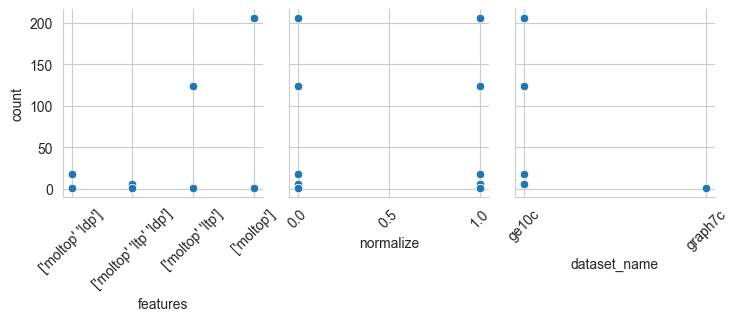

In [9]:

g = sns.pairplot(test_data.drop(columns=['result']), 
             y_vars=['count'],
             x_vars=['features', 'normalize', 'dataset_name'],
             )

for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(45)